In [9]:
import os
import copy
import torch
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

In [24]:
# ===========================
# Hyper Parameters
# ===========================
BATCH_SIZE = 256
LEARNING_RATE = 0.01
MOMENTUM = 0.5
EPOCH = 10

In [11]:
# ===========================
# Image Transform
# ===========================
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

In [13]:
class CustomJpgDataset(Dataset):
    def __init__(self, root_dir, is_train=True, transform=None):
        self.root_dir = root_dir
        self.is_train = is_train
        self.transform = transform
        self.img_list = []
        # 遍历文件夹所有jpg
        for fname in os.listdir(root_dir):
            # 兼容 .jpg / .JPG 大小写后缀
            if not fname.lower().endswith(".jpg"):
                continue
            # 拆分前缀
            prefix = fname.split("_")[0]
            # 训练集匹配 training_，测试集匹配 test_
            if self.is_train and prefix == "training":
                self.img_list.append(fname)
            elif not self.is_train and prefix == "test":
                self.img_list.append(fname)
        self.img_list = sorted(self.img_list)
        # 调试打印，确认读取数量
        print(f"is_train={self.is_train}，加载样本总数：{len(self.img_list)}")

    def __len__(self):
        return len(self.img_list)

    def __getitem__(self, idx):
        img_name = self.img_list[idx]
        img_path = os.path.join(self.root_dir, img_name)
        # 分割文件名取标签：training_57379_8.jpg → 最后一段数字8
        label_str = img_name.split("_")[-1].replace(".jpg", "")
        label = int(label_str)
        # 读取灰度图
        image = Image.open(img_path).convert("L")
        if self.transform is not None:
            image = self.transform(image)
        return image, label

In [14]:
# ===========================
# Load Dataset
# ===========================

DATA_DIR = "./mnist_jpg"

train_dataset = CustomJpgDataset(
    root_dir=DATA_DIR,
    is_train=True,
    transform=transform
)

test_dataset = CustomJpgDataset(
    root_dir=DATA_DIR,
    is_train=False,
    transform=transform
)

is_train=True，加载样本总数：60000
is_train=False，加载样本总数：10000


In [25]:
# ===========================
# DataLoader
# ===========================
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=8,
    pin_memory=True,
    persistent_workers=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=8,
    pin_memory=True,
    persistent_workers=True
)

In [26]:
print("=" * 50)
print("Training Samples :", len(train_dataset))
print("Testing Samples  :", len(test_dataset))
print("=" * 50)

Training Samples : 60000
Testing Samples  : 10000


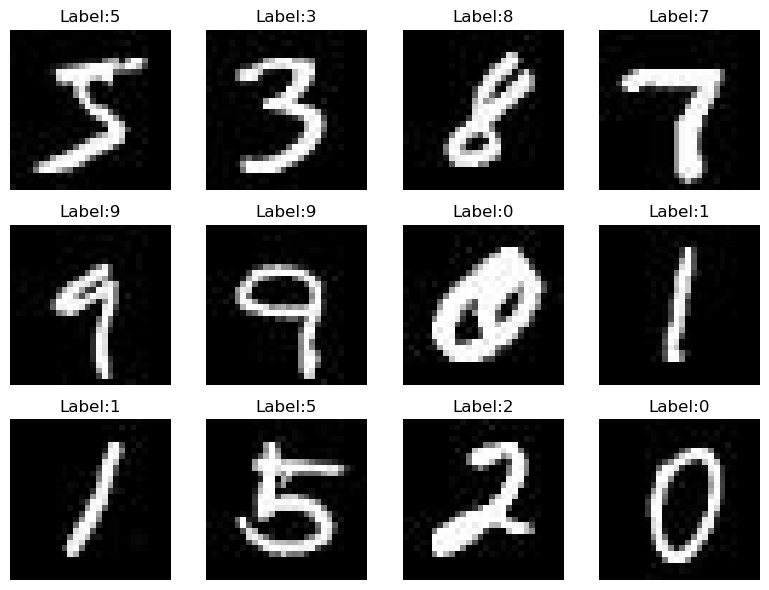

In [27]:
# ===========================
# Visualize Dataset
# ===========================

plt.figure(figsize=(8,6))

for i in range(12):

    image, label = train_dataset[i]

    image = image.squeeze(0).numpy()

    plt.subplot(3,4,i+1)

    plt.imshow(image,cmap="gray")

    plt.title(f"Label:{label}")

    plt.axis("off")

plt.tight_layout()

plt.show()

In [28]:
# ===========================
# CNN Model
# ===========================

class Net(torch.nn.Module):

    def __init__(self, activation="relu"):

        super(Net, self).__init__()

        # 根据输入字符串选择激活函数
        if activation == "relu":
            act = torch.nn.ReLU()

        elif activation == "sigmoid":
            act = torch.nn.Sigmoid()

        elif activation == "tanh":
            act = torch.nn.Tanh()

        else:
            raise ValueError("Unsupported activation!")

        self.conv1 = torch.nn.Sequential(

            torch.nn.Conv2d(
                in_channels=1,
                out_channels=10,
                kernel_size=5
            ),

            act,

            torch.nn.MaxPool2d(2)

        )

        self.conv2 = torch.nn.Sequential(

            torch.nn.Conv2d(
                in_channels=10,
                out_channels=20,
                kernel_size=5
            ),

            act,

            torch.nn.MaxPool2d(2)

        )

        self.fc = torch.nn.Sequential(

            torch.nn.Linear(320,50),

            act,

            torch.nn.Linear(50,10)

        )

    def forward(self,x):

        batch_size = x.size(0)

        x = self.conv1(x)

        x = self.conv2(x)

        x = x.view(batch_size,-1)

        x = self.fc(x)

        return x

In [29]:
def train(model,
          train_loader,
          criterion,
          optimizer):

    model.train()

    running_loss = 0

    correct = 0

    total = 0

    for images,labels in train_loader:

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs,labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _,predicted = torch.max(outputs.data,1)

        total += labels.size(0)

        correct += (predicted==labels).sum().item()

    epoch_loss = running_loss/len(train_loader)

    epoch_acc = correct/total

    return epoch_loss,epoch_acc

In [30]:
def test(model,test_loader):

    model.eval()

    correct = 0

    total = 0

    with torch.no_grad():

        for images,labels in test_loader:

            outputs = model(images)

            _,predicted = torch.max(outputs.data,1)

            total += labels.size(0)

            correct += (predicted==labels).sum().item()

    return correct/total

In [31]:
def run_experiment(activation):

    print("="*60)

    print(f"Activation : {activation}")

    print("="*60)

    model = Net(activation)

    criterion = torch.nn.CrossEntropyLoss()

    optimizer = torch.optim.SGD(
        model.parameters(),
        lr=LEARNING_RATE,
        momentum=MOMENTUM
    )

    train_loss = []

    train_acc = []

    test_acc = []

    for epoch in range(EPOCH):

        loss,acc=train(
            model,
            train_loader,
            criterion,
            optimizer
        )

        test_accuracy=test(
            model,
            test_loader
        )

        train_loss.append(loss)

        train_acc.append(acc)

        test_acc.append(test_accuracy)

        print(
            f"Epoch {epoch+1:2d} | "
            f"Loss={loss:.4f} | "
            f"Train={acc*100:.2f}% | "
            f"Test={test_accuracy*100:.2f}%"
        )

    return train_loss,train_acc,test_acc

In [32]:
relu_loss,relu_train,relu_test = run_experiment("relu")

sigmoid_loss,sigmoid_train,sigmoid_test = run_experiment("sigmoid")

tanh_loss,tanh_train,tanh_test = run_experiment("tanh")

Activation : relu
Epoch  1 | Loss=1.1707 | Train=66.80% | Test=90.38%
Epoch  2 | Loss=0.2466 | Train=92.75% | Test=94.43%
Epoch  3 | Loss=0.1691 | Train=95.04% | Test=95.81%
Epoch  4 | Loss=0.1330 | Train=96.03% | Test=95.90%
Epoch  5 | Loss=0.1108 | Train=96.71% | Test=97.16%
Epoch  6 | Loss=0.0969 | Train=97.04% | Test=97.36%
Epoch  7 | Loss=0.0887 | Train=97.32% | Test=97.36%
Epoch  8 | Loss=0.0803 | Train=97.56% | Test=97.93%
Epoch  9 | Loss=0.0740 | Train=97.74% | Test=97.94%
Epoch 10 | Loss=0.0701 | Train=97.80% | Test=97.99%
Activation : sigmoid
Epoch  1 | Loss=2.3042 | Train=11.06% | Test=11.35%
Epoch  2 | Loss=2.3009 | Train=11.24% | Test=11.35%
Epoch  3 | Loss=2.3006 | Train=11.30% | Test=11.35%
Epoch  4 | Loss=2.3001 | Train=11.24% | Test=11.35%
Epoch  5 | Loss=2.2995 | Train=11.25% | Test=17.29%
Epoch  6 | Loss=2.2989 | Train=11.62% | Test=11.35%
Epoch  7 | Loss=2.2983 | Train=11.24% | Test=11.35%
Epoch  8 | Loss=2.2975 | Train=11.24% | Test=11.35%
Epoch  9 | Loss=2.2964 | 

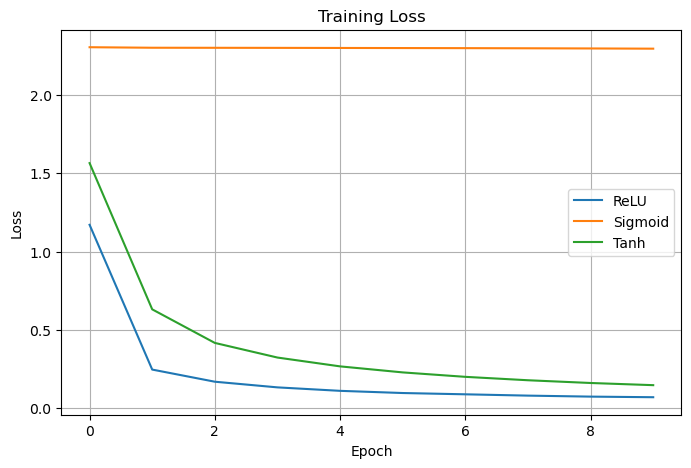

In [33]:
plt.figure(figsize=(8,5))

plt.plot(relu_loss,label="ReLU")

plt.plot(sigmoid_loss,label="Sigmoid")

plt.plot(tanh_loss,label="Tanh")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Training Loss")

plt.legend()

plt.grid()

plt.show()

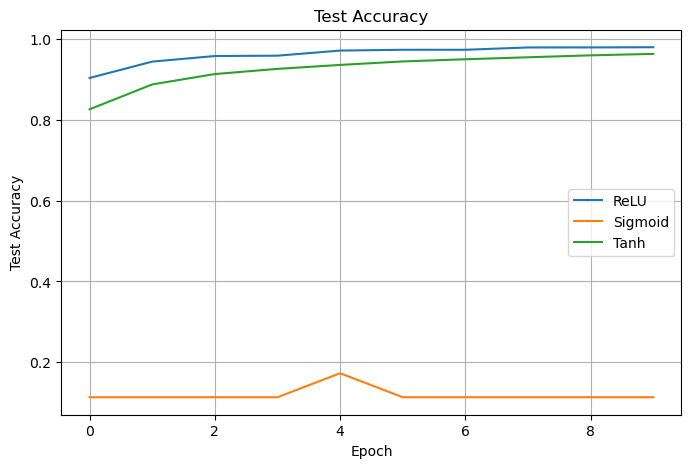

In [34]:
plt.figure(figsize=(8,5))

plt.plot(relu_test,label="ReLU")

plt.plot(sigmoid_test,label="Sigmoid")

plt.plot(tanh_test,label="Tanh")

plt.xlabel("Epoch")

plt.ylabel("Test Accuracy")

plt.title("Test Accuracy")

plt.legend()

plt.grid()

plt.show()

In [35]:
print("\n================ Final Result ================\n")

print(f"ReLU     : {relu_test[-1]*100:.2f}%")

print(f"Sigmoid  : {sigmoid_test[-1]*100:.2f}%")

print(f"Tanh     : {tanh_test[-1]*100:.2f}%")


================ Final Result ================

ReLU     : 97.99%
Sigmoid  : 11.35%
Tanh     : 96.34%


## 激活函数消融实验结果分析

本实验在保持网络结构、训练数据集及超参数完全一致的条件下（Batch Size=256，Learning Rate=0.01，Momentum=0.5，Epoch=10），仅将网络中的激活函数分别设置为 **ReLU**、**Sigmoid** 和 **Tanh**，比较不同激活函数对模型收敛速度和最终分类性能的影响。

实验结果表明，**ReLU** 的表现最佳。模型在第1个Epoch便达到90.38%的测试准确率，并在第10个Epoch达到97.99%，Loss持续下降且收敛速度最快。这是因为ReLU在正区间梯度恒为1，不易发生梯度消失，能够有效促进深层网络参数更新，因此训练过程稳定，最终获得了最高的分类精度。

**Sigmoid** 的表现最差，训练过程中Loss始终维持在2.30左右，训练准确率约为11%，测试准确率基本保持在11.35%，接近MNIST十分类任务随机猜测的水平，模型几乎没有学习到有效特征。其主要原因是Sigmoid函数容易进入饱和区，当输入值较大或较小时，梯度接近于0，导致梯度消失，使网络参数更新十分缓慢。此外，本实验为了保证消融实验的公平性，三种激活函数均采用相同的超参数，其中学习率设置为0.01、训练轮数为10轮，并未针对Sigmoid进行单独调参，因此其梯度消失问题更加明显，最终未能有效收敛。

**Tanh** 的性能介于两者之间。模型最终测试准确率达到96.34%，明显优于Sigmoid，但略低于ReLU。由于Tanh函数输出以0为中心，相比Sigmoid具有更好的梯度传播能力，因此收敛速度有所提升；但其仍然存在梯度饱和现象，因此整体训练效率和最终分类性能仍逊于ReLU。

综合实验结果可以看出，在相同网络结构和训练参数下，ReLU具有最快的收敛速度和最高的分类准确率；Tanh能够取得较好的分类效果，但收敛速度较慢；Sigmoid由于梯度消失问题，在当前实验设置下几乎无法完成有效训练。因此，在现代卷积神经网络中，ReLU仍然是最常用且性能最稳定的激活函数。
